# Vertical coordinates

This notebook contains figures that relate to vertical coordinates used in the model runs.
Plotted here is the initial vertical coordinate i.e. that which is computed from the grid cell thickness `thkcello` at the first saved value.
The coordinates are from the middle of the zonal range (`Nx = 160` $\implies$ midpoint at index `80`).
I have used the `monthly` output.

**NOTE:** hycom appears to have one less layer of thickness at the bottom of the domain. Not quite sure why.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Precompiling NCDatasets [85f8d34a-cbdd-5861-8df4-14fed0d494ab] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] (cache misses: dep missing source (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught

In [2]:
expts = ("zstar-PPMH3", "hycom-PPMH3") # just gets order as I want it

("zstar-PPMH3", "hycom-PPMH3")

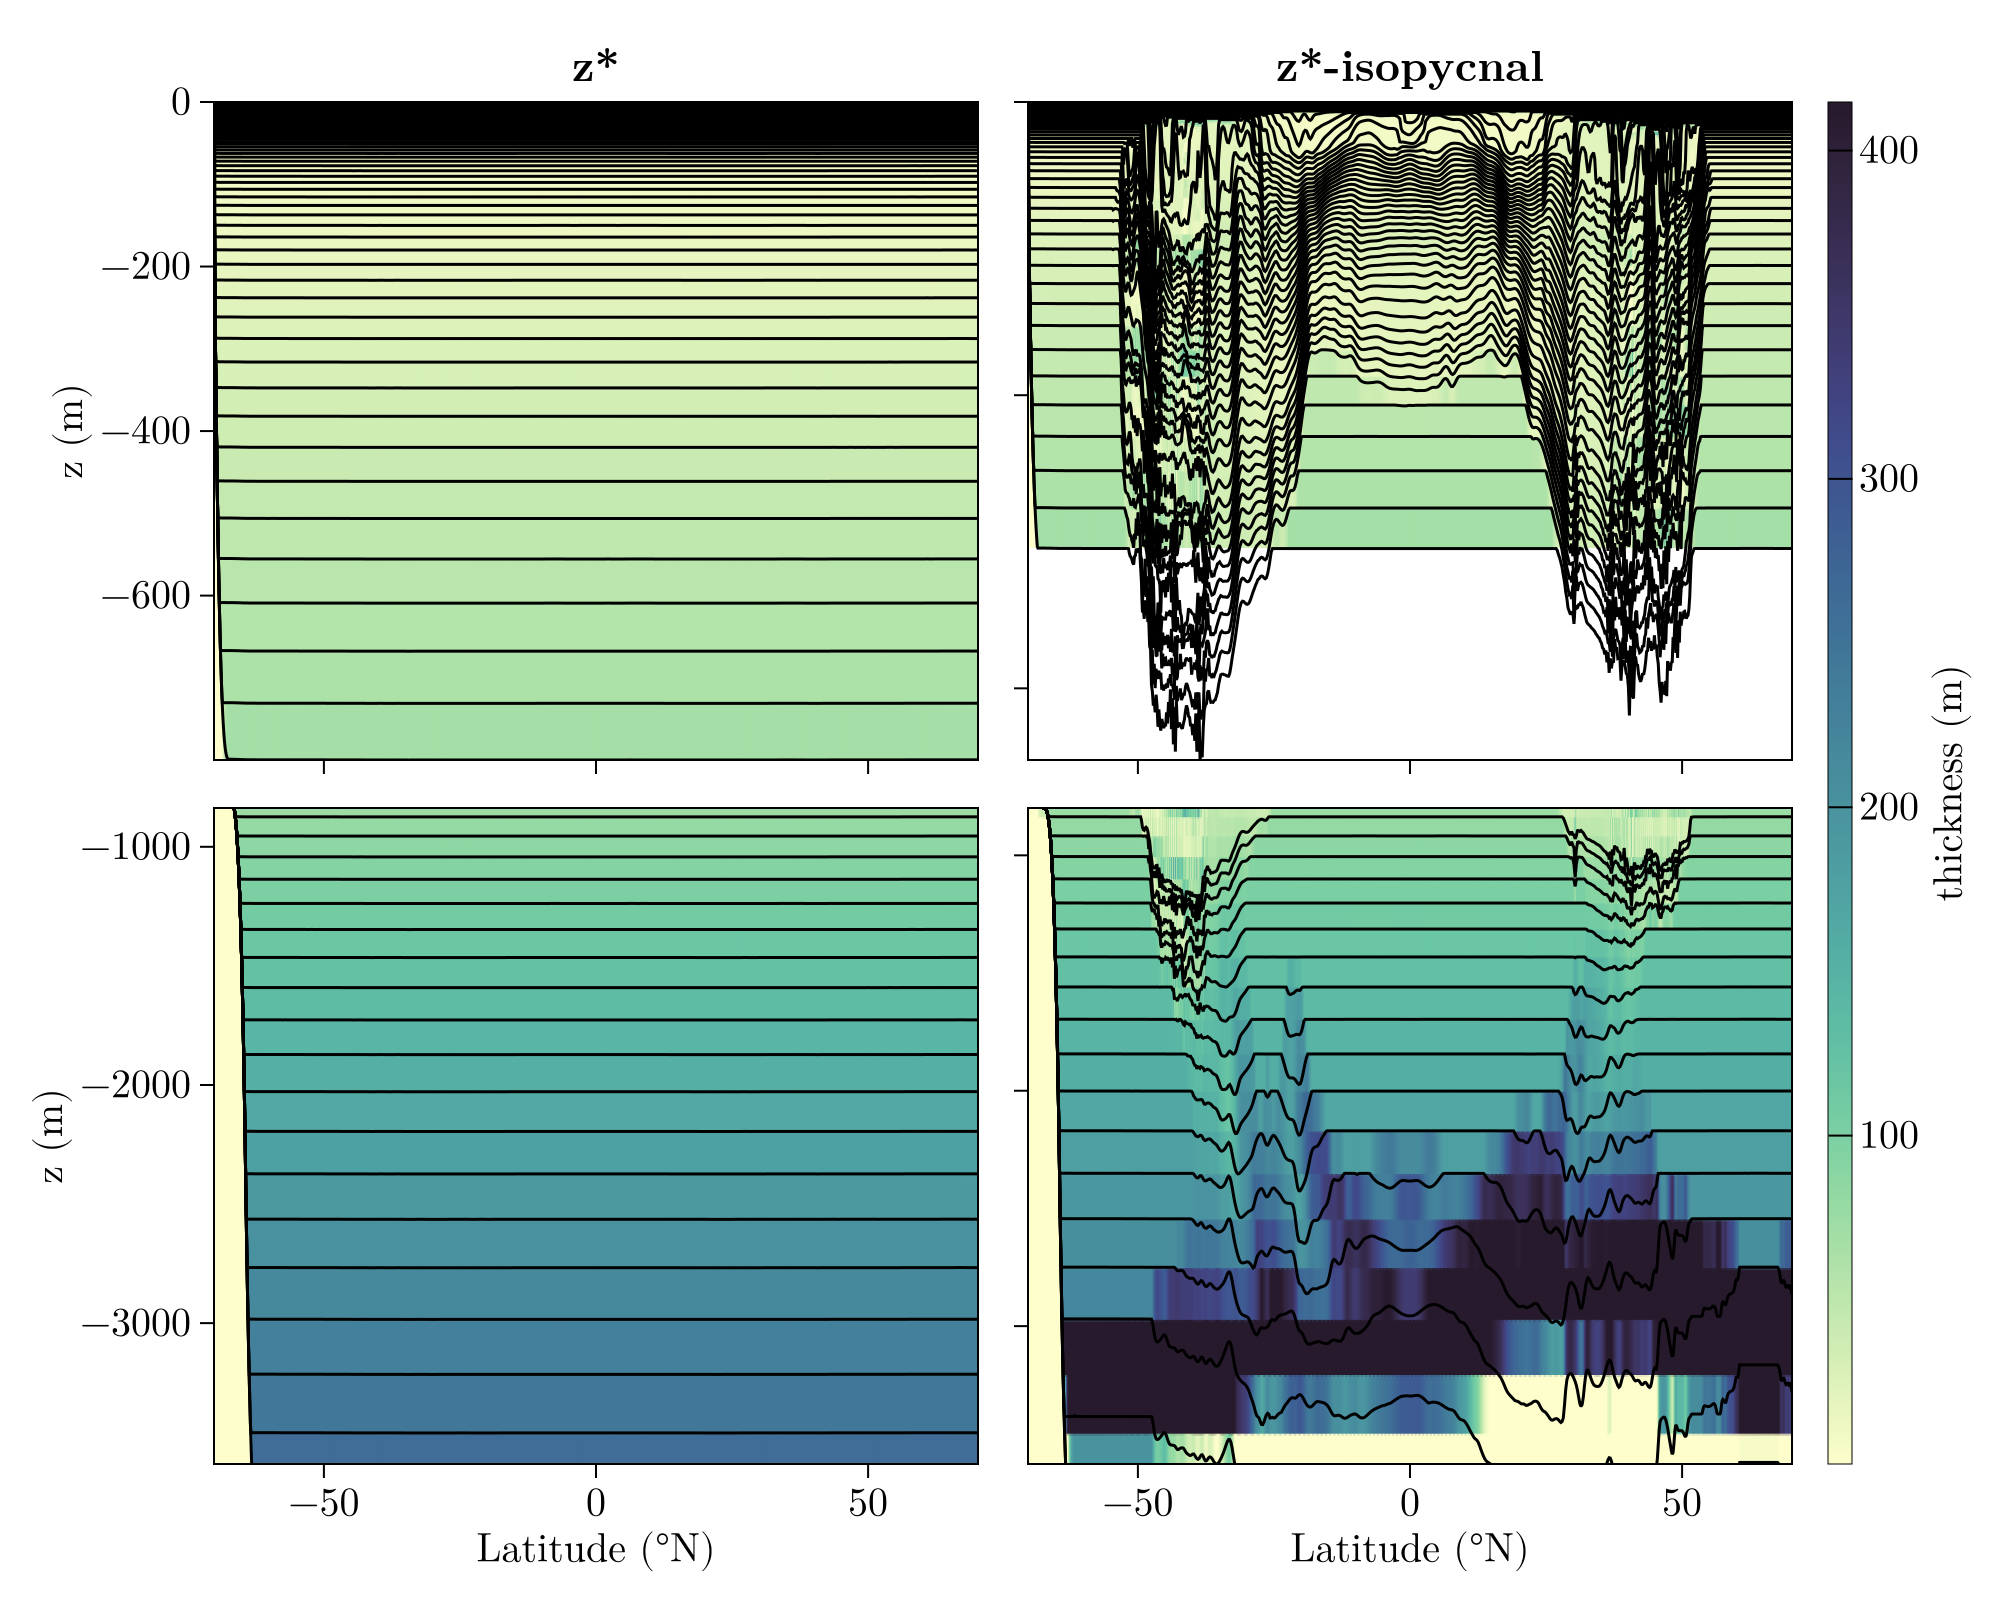

In [3]:
fig = Figure(size = (1000, 800))

titles = ("z*", "z*-isopycnal")
colorrange = NCDataset(catalogue["hycom-PPMH3"]["monthly"], maskingvalue = NaN) do ds
    h = ds["thkcello"][40, :, :, 1] # middle of domain
    (nanminimum(h), nanmaximum(h))
end

for (j, k) ∈ enumerate(expts)
    
    crs = get_geo_coords(catalogue[k]["static"], catalogue[k]["vc"])
    
    ds = NCDataset(catalogue[k]["monthly"], maskingvalue = NaN)
    h = ds["thkcello"][40, :, :, 1] # middle of domain
    close(ds)

    ∫h = cumsum(h, dims = 2)

    top = 1:55
    bot = top[end]+1:74

    axtop = Axis(fig[1, j], xlabel = "Latitude (°N)", ylabel = "z (m)", title = titles[j])
    hidexdecorations!(axtop, ticks = false)
    hm = heatmap!(axtop, crs.lath, crs.zl[top], h[:, top]; colorrange, colormap = :deep)
    for i ∈ top
        lines!(axtop, crs.lath, -∫h[:, i], color = :black)
    end
    axbot = Axis(fig[2, j], xlabel = "Latitude (°N)", ylabel = "z (m)")
    hm = heatmap!(axbot, crs.lath, crs.zl[bot], h[:, bot]; colorrange, colormap = :deep)
    for i ∈ bot
        lines!(axbot, crs.lath, -∫h[:, i], color = :black)
    end
    ylims!(axbot, crs.zl[bot[end]], crs.zl[bot[1]])
    if  j == 2 
        hideydecorations!(axtop, ticks = false)
        hideydecorations!(axbot, ticks = false)
        Colorbar(fig[1:2, j+1], hm, label = "thickness (m)")
    end

end
rowsize!(fig.layout, 1, Relative(1/2))
fig

## Comparison to what is seen in ANU-TUB repo

Initially when looking at the vertical grid, Jan pointed out there is not too much going on at the boundaries and interior ocean (where there should be).
Andy and Angus have a vertical structure comparison notebook, see [here](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/VerticalStructureComparison.ipynb), where you can see the vertical structure in the deep ocean is much more wiggly (i.e. not following z star).

Below I think I replicate the code they used to generate their figure yet there is still not much going on in the deep ocean.
Their code is looking at a much later date (at least that is what gemini suggested).
The `n` argument selects the last 200 snapshots and the `issel(time=0)` takes the first of these.

Could it be that some of the vertical structure evolves only after the simulation has been run for a long time?
Or perhaps there is something not going quite right with restart?
Might need to ask them if nothing else appears.

In [4]:
ds = NCDataset(catalogue["hycom-PPMH3"]["monthly"], maskingvalue = NaN)
# ds = NCDataset(catalogue["zstar-PPMH3"]["monthly"], maskingvalue = NaN) # check
h = ds["thkcello"][80, :, :, 1]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, 1]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

closed Dataset

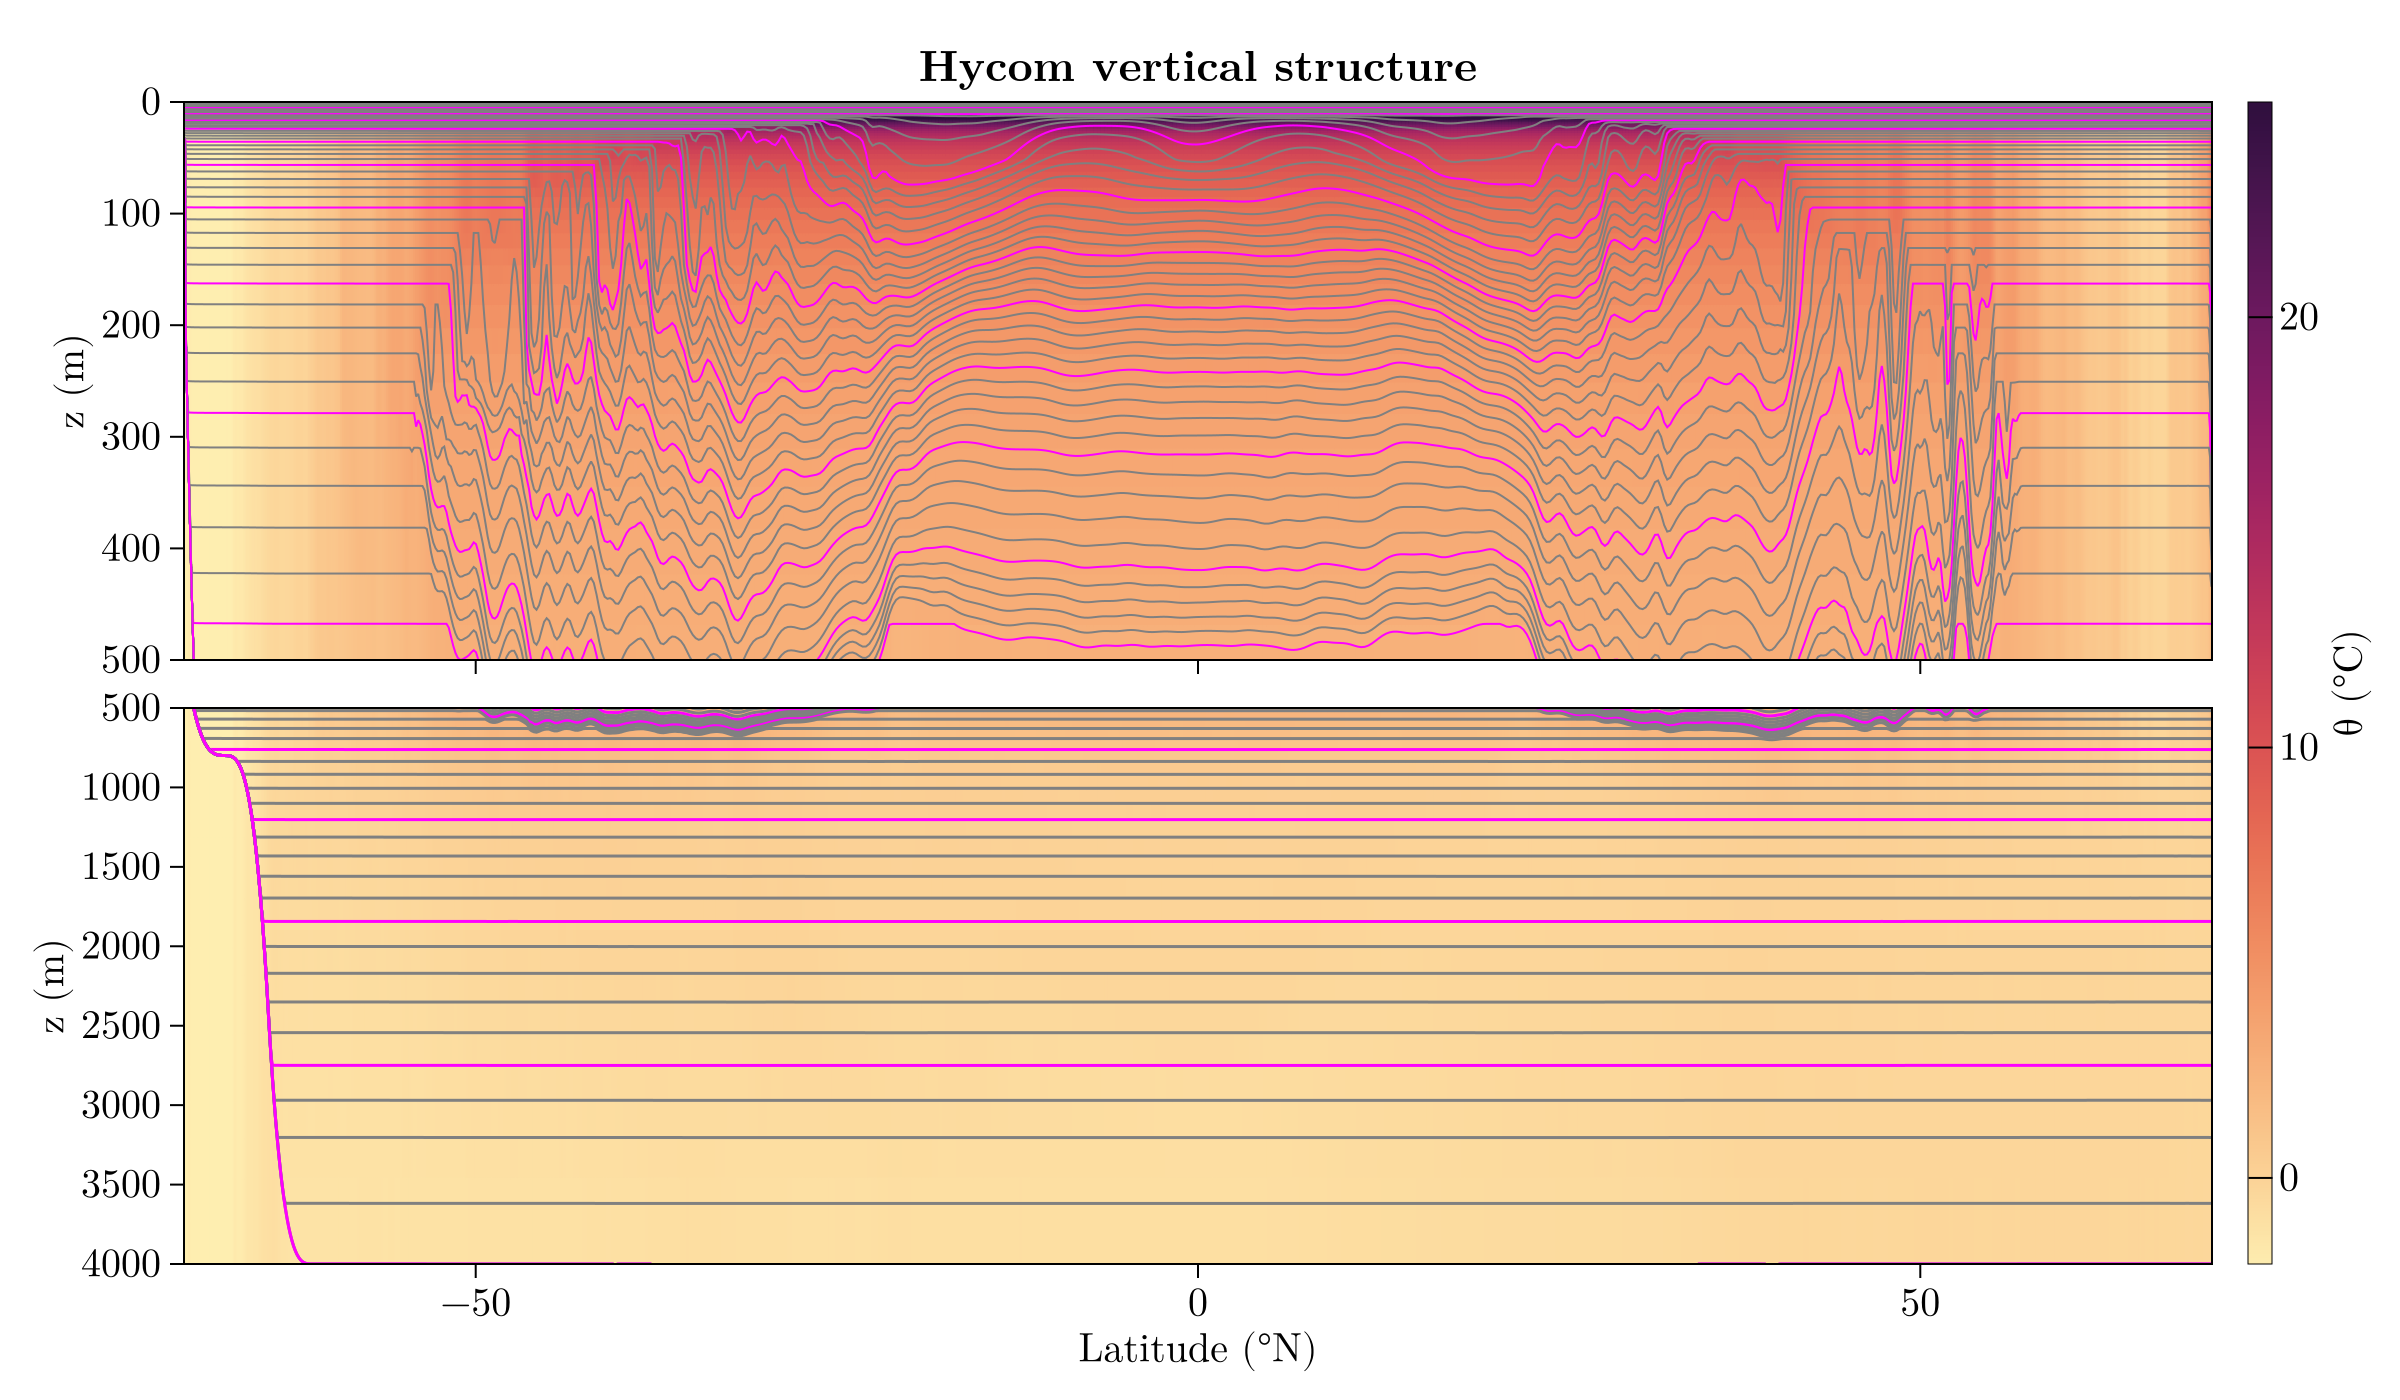

In [16]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Hycom vertical structure")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "θ (°C)")

fig

In [21]:
save("theta_hycom_grid_initial.png", fig)

## Comparison to some output from Andy Hogg

I am trying to compare my code to plot the scripts to a [hycom experiment vertical grid](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/VerticalStructureComparison.ipynb) in one of Andy and Agnus' diagnostic notebooks.
The data plotted in the linked figure is:

```python
darray = cc.querying.getvar(experiment, 'thkcello', session,ncfile='ocean_month.nc',n=-200).isel(time=0)
depth = darray.isel(xh=40).cumsum('zl').values
darray = cc.querying.getvar(experiment, 'thetao', session,ncfile='ocean_month.nc',n=-200).isel(time=0)

theta = xr.DataArray(data=darray.isel(xh=40).values,dims=["zl", "yh"],
        coords=dict(yh=(["yh"], darray.yh.values),depth=(["zl", "yh"], depth)),
        attrs= darray.attrs)
```

**NOTE:** here is the docstring for n in the function [getvar](https://github.com/COSIMA/cosima-cookbook/blob/c945ef9405bd8ad350f66aa82c44a68da43606aa/cosima_cookbook/querying.py#L275).

```
    n - after all other queries, restrict the total number of files to the
        first n. pass a negative value to restrict to the last n
```

where `experiment` and `session` are from a `cosima_cookbook.database`.
The kwarg `n = -200` indicates they take the last 200 files, then access this at the first time index.
Assuming the data in the directory `anu-tub-hycom1-500` is what is in the `cc.database` (which may not be the case given the slightly different naming and 500 would suggest 500 years, not 1000 like the others), the `getvar` command above would load the variable from the last 200 files (there are a lot less than this) and take the first snapshot.

**UPDATE:** I think the `-500` appending looks like it is different to the `hycom` runs that are missing this; see [here](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/SimpleComparison.ipynb) where there is:

```python
experiments=['anu-tub-n3','anu-tub-hycom1','anu-tub-adapt','anu-tub-n4','anu-tub-hycom1-500',]
```

To try and get a comparsions I can instead look at one of the adapt runs in the hope that I can reproduce a figure similar to that in Anyd and Angus's work.

For `anu-tub-adapt-n6` the code to get the variable is:

```python
    darray = cc.querying.getvar(experiment, 'thkcello', session,ncfile='ocean_month.nc',n=-1,decode_times=False).isel(time=0)
    depth = darray.isel(xh=40).cumsum('zl').values
    darray = cc.querying.getvar(experiment, 'thetao', session,ncfile='ocean_month.nc',n=-1,decode_times=False).isel(time=0)
    
    theta = xr.DataArray(data=darray.isel(xh=40).values,dims=["zl", "yh"],
            coords=dict(yh=(["yh"], darray.yh.values),depth=(["zl", "yh"], depth)),
            attrs= darray.attrs)
```
so I assume it would be the last file in the output; in this case directory `output482`.
I think that the comparison between these two plots shows that the code is able to correctly plot things; see the [equivalent plot in this notebook](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/SimpleComparison.ipynb).

In [40]:
# Hogg_run = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-hycom1-500/output342/ocean_month.nc" # HYCOM
Hogg_run = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-adapt-n6/output482/ocean_month.nc" # adaptive coordinate

"/g/data/x77/amh157/anu-tub/outputs/anu-tub-adapt-n6/output482/ocean_month.nc"

In [41]:
ds = NCDataset(Hogg_run)
xh = ds["xh"][:]
h = ds["thkcello"][41, :, :, 1]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][41, :, :, 1]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

closed Dataset

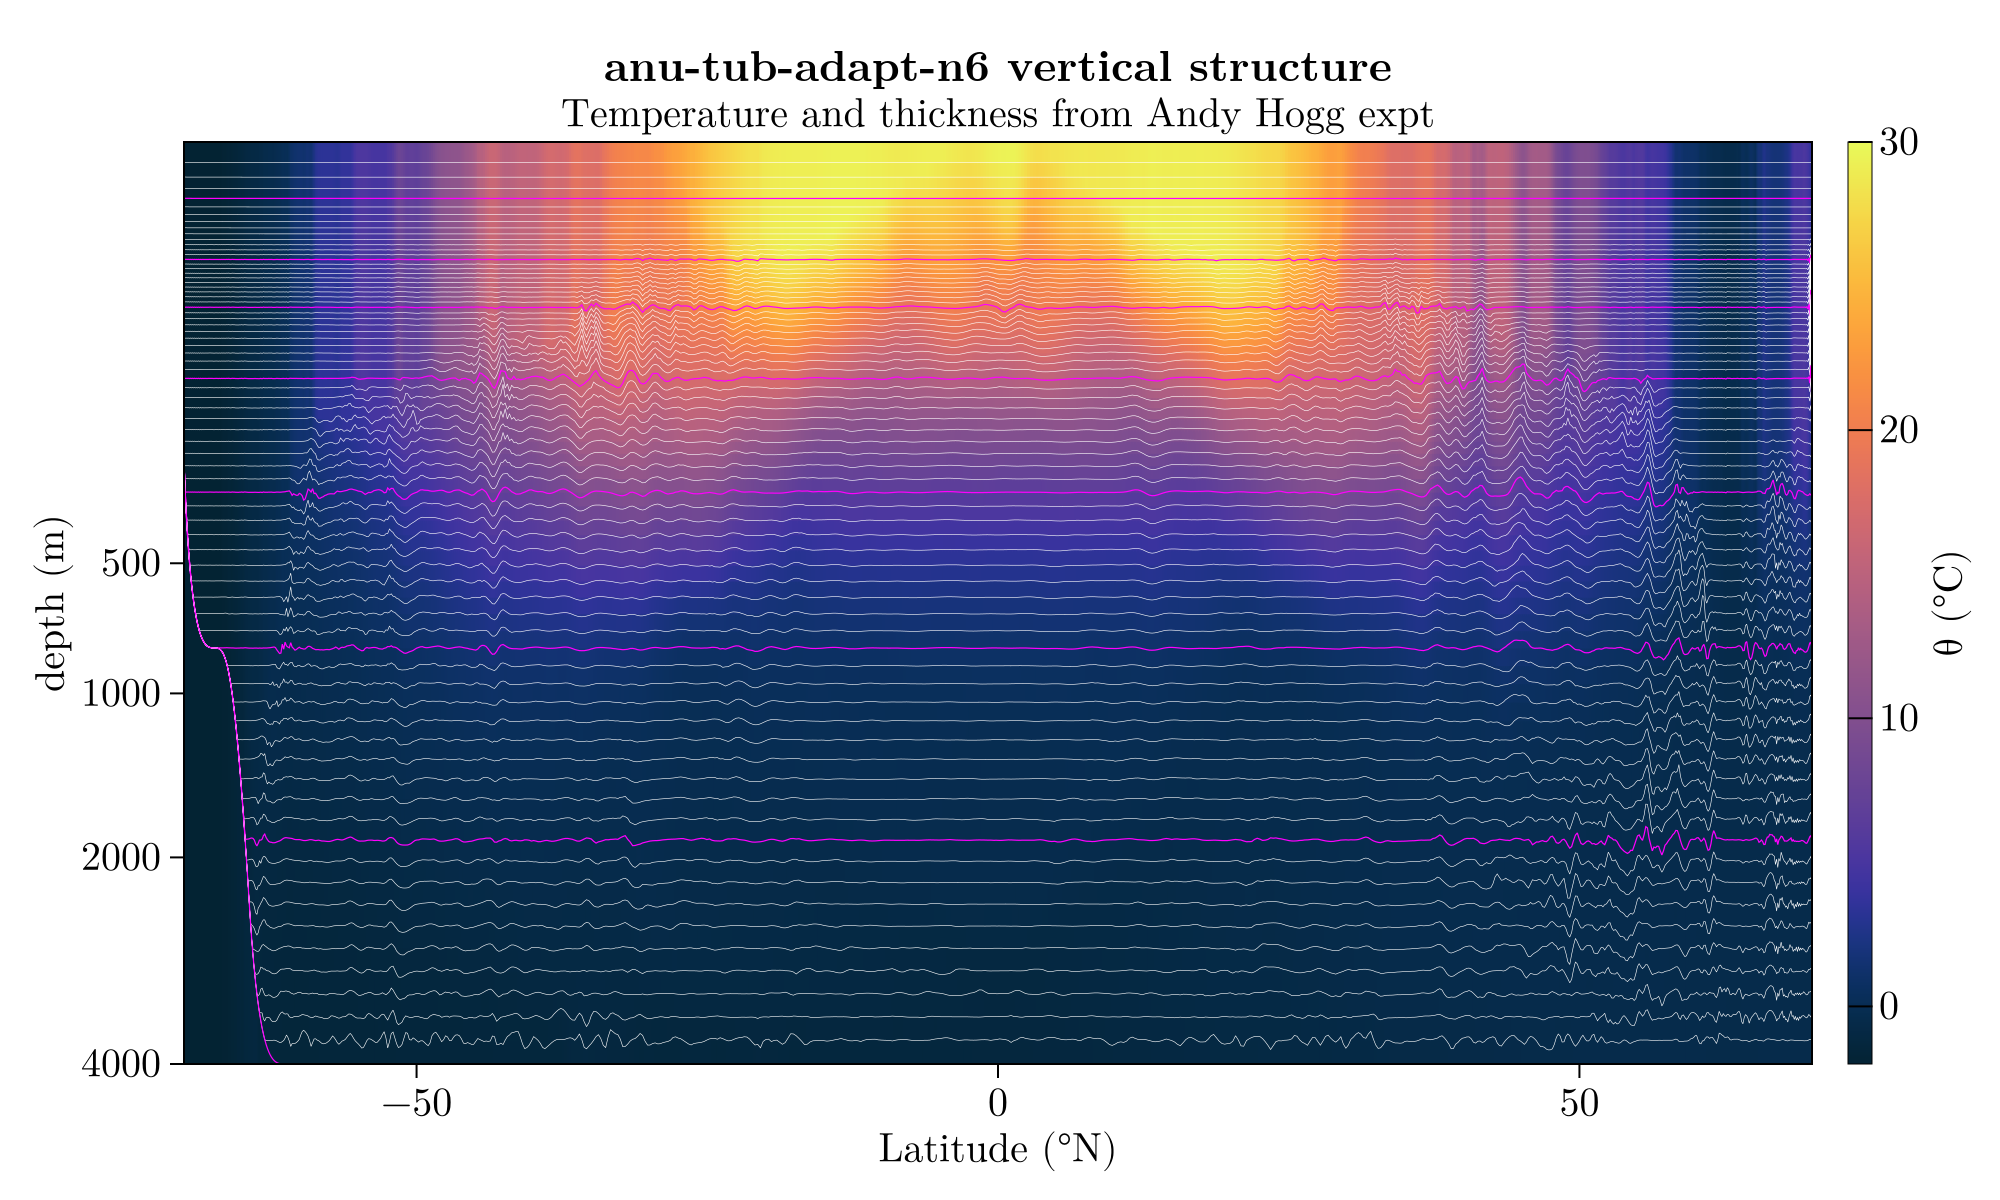

In [42]:
fig = Figure(size = (1000, 600))

# ## Hcyom
# colorrange = (-2, 28)
# colormap = :matter
# depth_levels = 1:75
# axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
#             title = "Hycom vertical structure", subtitle = "Initial temperature and thickness from my HYCOM ics")
# hidexdecorations!(axtop, ticks = false)
# hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
# for i ∈ depth_levels
#     if i % 5 == 0
#         lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
#     else
#         lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
#     end
# end
# ylims!(axtop, 0, 500)
# axtop.yreversed = true

# axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
# hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
# for i ∈ depth_levels
#     if i % 5 == 0
#         lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
#     else
#         lines!(axbot, yh, ∫h_test[:, i], color = :grey)
#     end
# end
# ylims!(axbot, 500, 4000)
# axbot.yreversed = true

# Colorbar(fig[1:2, 2], hm, label = "θ (°C)")

# fig

## adapt plotting
colorrange = (-2, 30)
colormap = :thermal
forward(x) = x^(1/3)
inverse(x) = x^3
my_cube_scale = Makie.ReversibleScale(forward, inverse)

ax = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", yscale = my_cube_scale, 
            title = "anu-tub-adapt-n6 vertical structure", subtitle = "Temperature and thickness from Andy Hogg expt")
hm = heatmap!(ax, yh, z, θ; colorrange, colormap)
for i ∈ depth_levels
    if mod1(i, 10) == 5
        lines!(ax, yh, ∫h_test[:, i], color = :magenta, linewidth = 0.6)
    else
        lines!(ax, yh, ∫h_test[:, i], color = :white, linewidth = 0.3)
    end
end
xlims!(ax, -70, 70)
ylims!(ax, 2, 4000)
ax.yticks = [500, 1000, 2000, 4000]
ax.yreversed = true


Colorbar(fig[1, 2], hm, label = "θ (°C)")

fig

This matches (as far as I can see) the equivalent figure in [this notebook](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/SimpleComparison.ipynb).

In [31]:
save("theta_hycom_grid_initial.png", fig)

## My initial conditions

In [ ]:
myrun = joinpath(@__DIR__, "anu-tub-nm-hycom-PPMH3", "output001", "ocean_month.nc") # my run with HYCOM S, T, and h initial conditions

In [ ]:
ds = NCDataset(myrun)
h = ds["thkcello"][80, :, :, 1]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, 1]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

In [ ]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
            title = "Hycom vertical structure", subtitle = "Initial temperature and thickness from my HYCOM ics")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "θ (°C)")

fig